# Компьютерная геометрия

При использовании выполнении всех заданий следует пользоваться объектно-ориентированным интерфейсом библиотеки Matplotlib. Также все изображения должны удовлетворять следующим требованиям:
-  Разрешение изображения должно быть не менее 200dpi.
- На всех изображениях должно присутствовать координатная сетка.
- Оси координат должны быть подписаны.
- Формулы должны иметь «математический» вид, например $x^2$, а не x^2 или $\sqrt{\sin(x)}$, а не sqrt(sin(x)) и т.д.
- Если используются буквы древнегреческого или русского языков, то они также должны отображаться корректно, например $\mu$, а не mu.

## Лабораторная работа №1

### Задание 1

Постройте декартову плоскость координат с осями 𝑂𝑥 и 𝑂𝑦, с разметкой по осям. На осях 𝑂𝑥 и 𝑂𝑦 отметьте целочисленные координаты в диапазоне [−𝑛, 𝑛], где 𝑛 — конкретное целое число. Координатная сетка на плоскости должна рисоваться автоматически. Границы (лимиты) осей задайте явно.

- Теперь отключите автоматическую координатную сетку и нарисуйте ее вручную так, чтобы вся плоскость покрылась квадратными клетками 1×1. Используйте функции, которые рисуют отрезки.
- Настройте вид линий, изменив цвет, стиль (пунктир, штрихпунктир, штрих и т.д.), толщину и т.д.
- Вновь нарисуйте координатную сетку, но теперь используйте функции для рисования бесконечных прямых.
- Нарисуйте теперь диагональные прямые, как это показано на рисунке 2.
- Программа должна работать так, чтобы правильно рисовать сетку при любом заданном целом 𝑛.

Вам понадобятся следующие функции из библиотеки Matplotlib: vlines, hlines, axvline, axhline,
axline. Какой математический смысл несет параметр slope в последней функции?

In [2]:
# Лабораторная работа №1, Задание №1
# Выполнено строго по 01.pdf, Рис. 1

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, ToggleButton

# ------------------------------------------------------------
# 1. Задаём точки отрезка P1 и P2 (лежат на прямой y = 0)
# ------------------------------------------------------------
P1 = np.array([-3, 0])   # левая граница основного отрезка
P2 = np.array([4, 0])    # правая граница основного отрезка

def lerp(p1, p2, t):
    """Линейная интерполяция: p(t) = p1*(1-t) + p2*t"""
    return p1 * (1 - t) + p2 * t

# Точка M – середина основного отрезка (t = 0.5)
M = lerp(P1, P2, 0.5)

# Точки M2 и M1 – для демонстрации выхода за границы (t = -0.5 и t = 1.5)
# Они лежат на той же прямой и являются границами длинного отрезка
M2 = lerp(P1, P2, -0.5)   # левая граница (фиолетовая)
M1 = lerp(P1, P2, 1.5)    # правая граница (синяя)

print("Координаты точек (все на прямой y = 0):")
print(f"  M2 (t=-0.5): ({M2[0]:.2f}, {M2[1]:.2f})")
print(f"  P1 (t=0):   ({P1[0]:.2f}, {P1[1]:.2f})")
print(f"  M (t=0.5):  ({M[0]:.2f}, {M[1]:.2f})")
print(f"  P2 (t=1):   ({P2[0]:.2f}, {P2[1]:.2f})")
print(f"  M1 (t=1.5): ({M1[0]:.2f}, {M1[1]:.2f})")

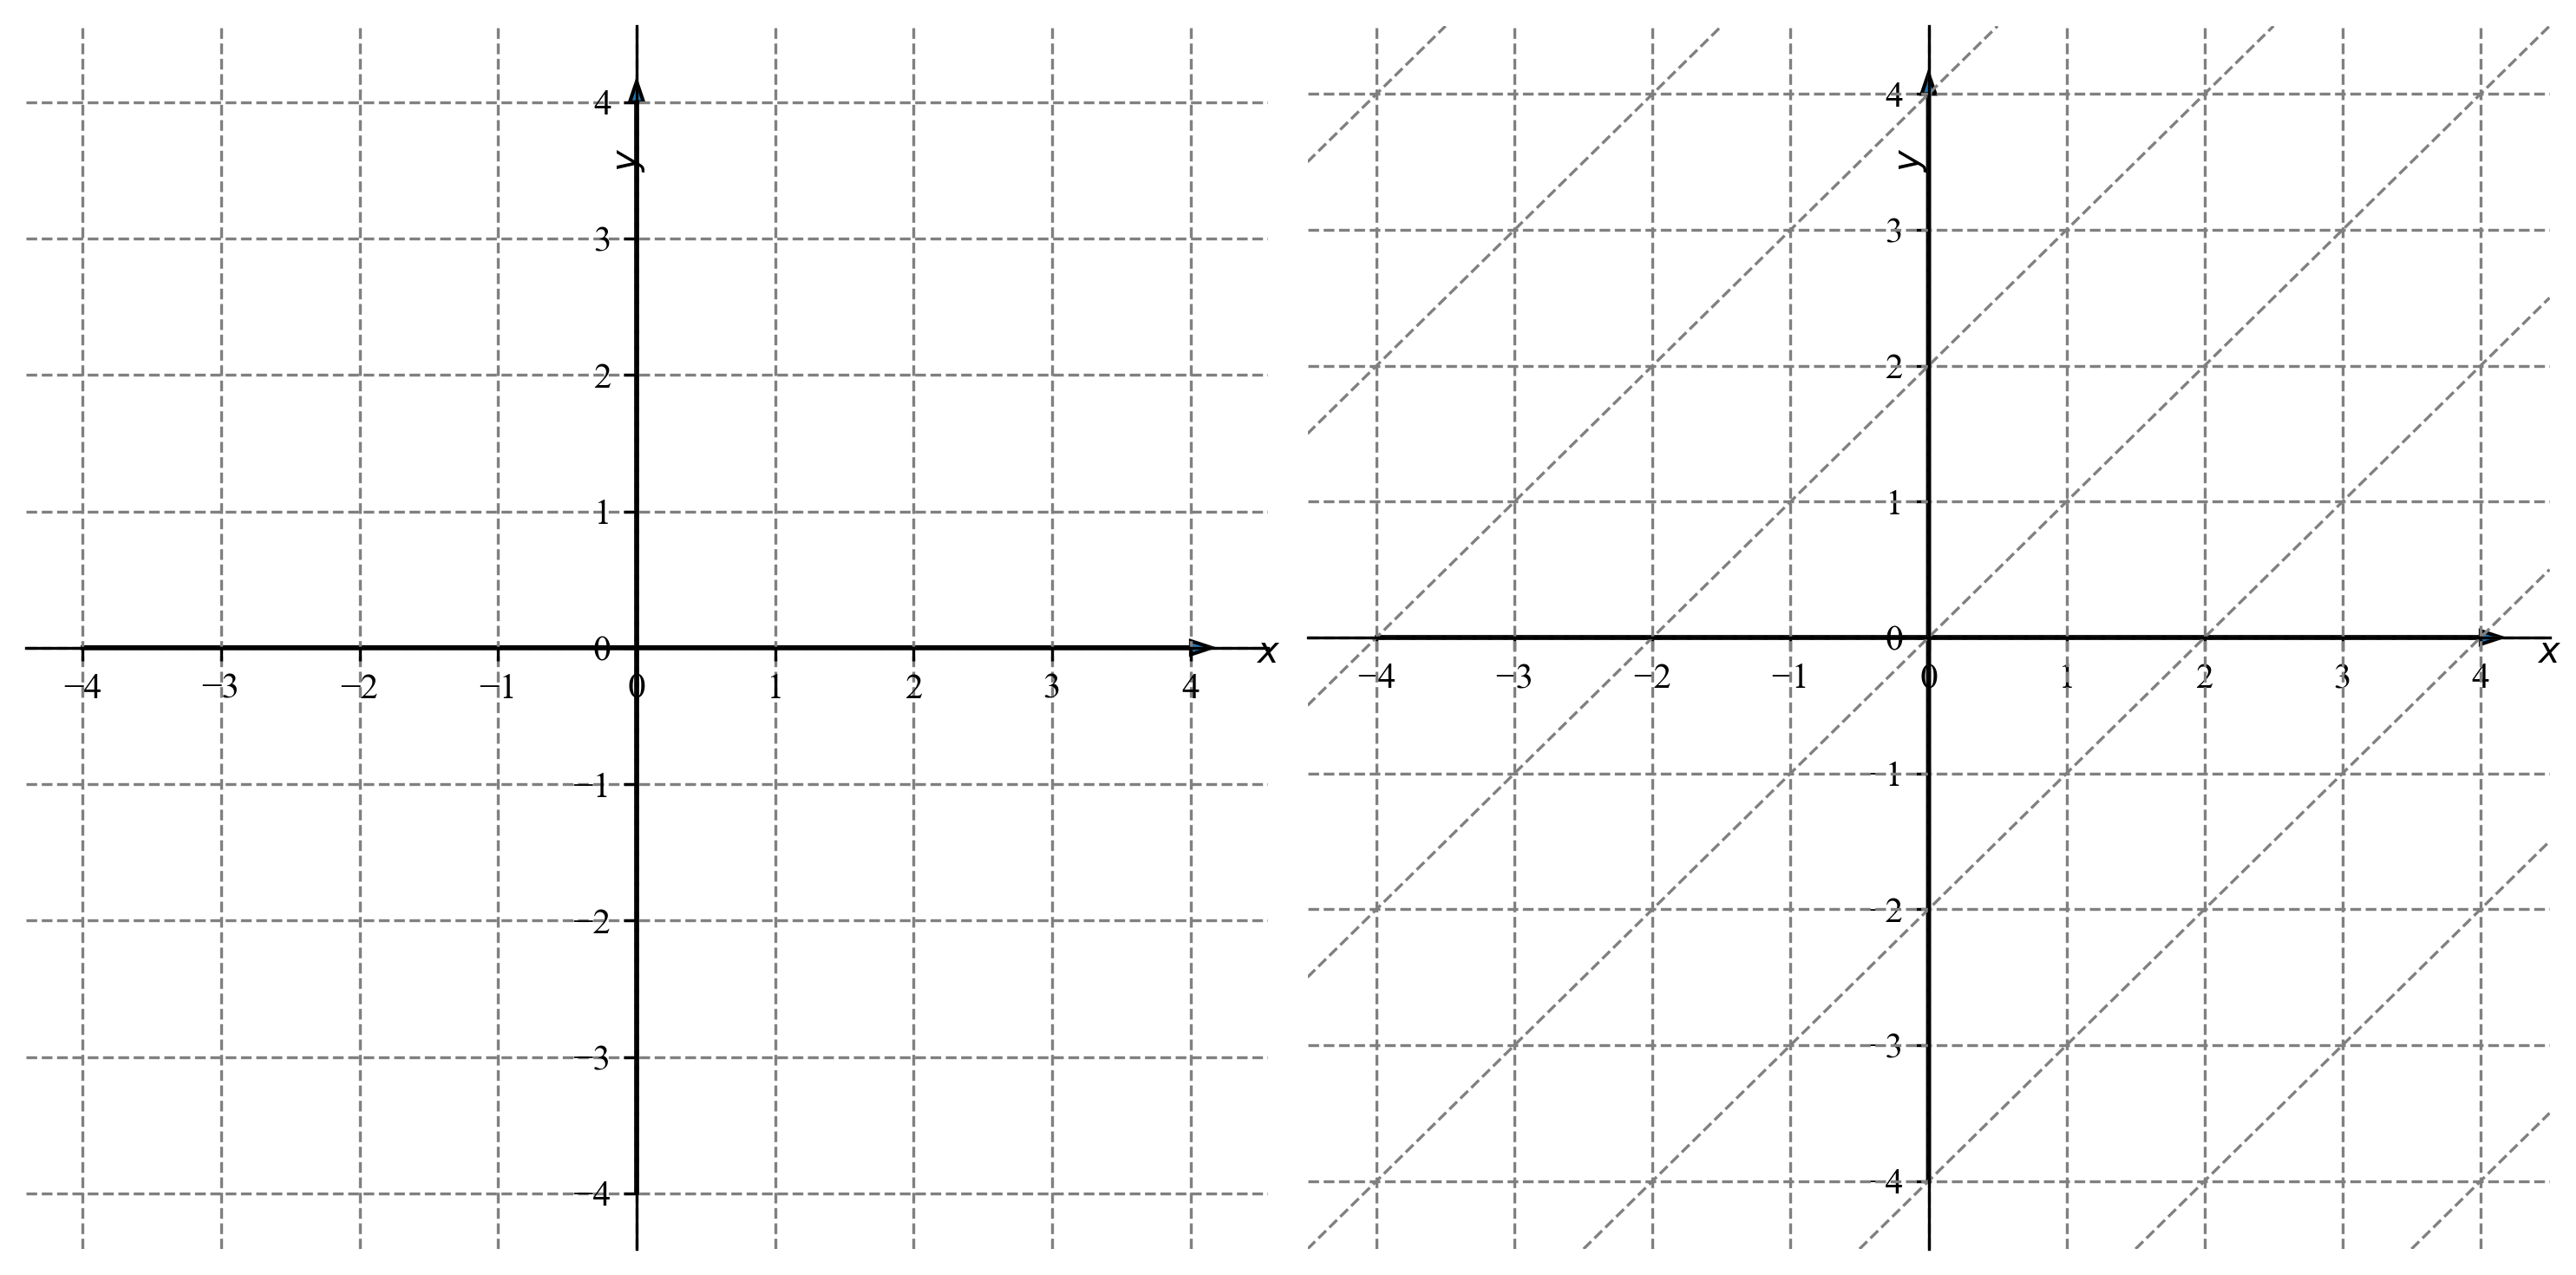

In [3]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.vlines(0, -N, N, color='black', linewidth=0.8)
ax1.hlines(0, -N, N, color='black', linewidth=0.8)

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')

ax1.xaxis.set_label_coords(1, 0.5) 
ax1.yaxis.set_label_coords(0.5, 0.89) 

ax1.grid(color='gray', linestyle='--', linewidth=0.8)


farrowx = mpatches.FancyArrow(x=-N, y=0, dx=2*N, dy=0, width=0.01, head_width=0.1)
farrowy = mpatches.FancyArrow(x=0, y=-N, dx=0, dy=2*N, width=0.01, head_width=0.1)

ax1.add_patch(farrowx)
ax1.add_patch(farrowy)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.spines['bottom'].set_position('zero')
ax1.spines['left'].set_position('zero')


ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.spines['bottom'].set_position('zero')
ax2.spines['left'].set_position('zero')


ax2.set_xlim((-N-0.5,N+0.5))
ax2.set_ylim((-N-0.5,N+0.5))


#for i in range(-N, N+1, 1):
#    n = N
#    # конечные линии:
#    ax2.axvline(x=i, ymin=-N, ymax=N, color = 'gray', linestyle='--', linewidth=0.8)
#    ax2.axhline(y=i, xmin=-N, xmax=N, color = 'gray', linestyle='--', linewidth=0.8)



# бесконечные:
for i in range(-N, N+1, 1):
    n = N
    ax2.axline((i, -N), (i, N), color = 'gray', linestyle='--', linewidth=0.8)
    ax2.axline((-N, i), (N, i), color = 'gray', linestyle='--', linewidth=0.8)
    ax2.axline((-i,i), slope=1, color = 'gray', linestyle='--', linewidth=0.8)
    n+=1

    
farrowx2 = mpatches.FancyArrow(x=-N, y=0, dx=2*N, dy=0, width=0.01, head_width=0.1)
farrowy2 = mpatches.FancyArrow(x=0, y=-N, dx=0, dy=2*N, width=0.01, head_width=0.1)

ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.xaxis.set_label_coords(1, 0.5) 
ax2.yaxis.set_label_coords(0.5, 0.89) 


ax2.add_patch(farrowx2)
ax2.add_patch(farrowy2)

fig.tight_layout()

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(axes_class=AxesZero)

plt.vlines(0, -N, N, color='black', linewidth=0.8)
plt.hlines(0, -N, N, color='black', linewidth=0.8)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.xaxis.set_label_coords (1, 1) 
ax.yaxis.set_label_coords (1, 1) 

for direction in ["xzero", "yzero"]:
    ax.axis[direction].set_axisline_style("-|>")
    ax.axis[direction].set_visible(True)

plt.grid(which='major', linestyle='--')

for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False) 
ax.yaxis.set_label_coords (0, 4)

for direction in ["left", "right", "bottom", "top"]:
    # hides borders
    ax.axis[direction].set_visible(False)

plt.rcParams["font.serif"] = ["Times New Roman"]
    
plt.show()

### Задание 2
- Нарисуйте два произвольных вектора. Найдите ориентированный угол между ними, для чего используйте функцию arctan2. Проверьте корректность вычислений на примерах острого, тупого и прямого углов.
- Примените к векторам такое линейное преобразование, чтобы ориентированный угол поменял свой знак. Какому условию должна удовлетворять матрица такого преобразования?
- Нарисуйте то же самое переключившись в полярную систему координат, получившееся изображения должно быть похоже на рисунки 3 и 4.

В библиотеке Matplotlib для рисования стрелок можно использовать функции arrow или annotate. Функция arctan2 есть как в NumPy, так и в стандартной библиотеке math.

2.356194490192345 0.6947382761967031
1.4801364395941514
95.1944289077348
[-45.          50.19442891]


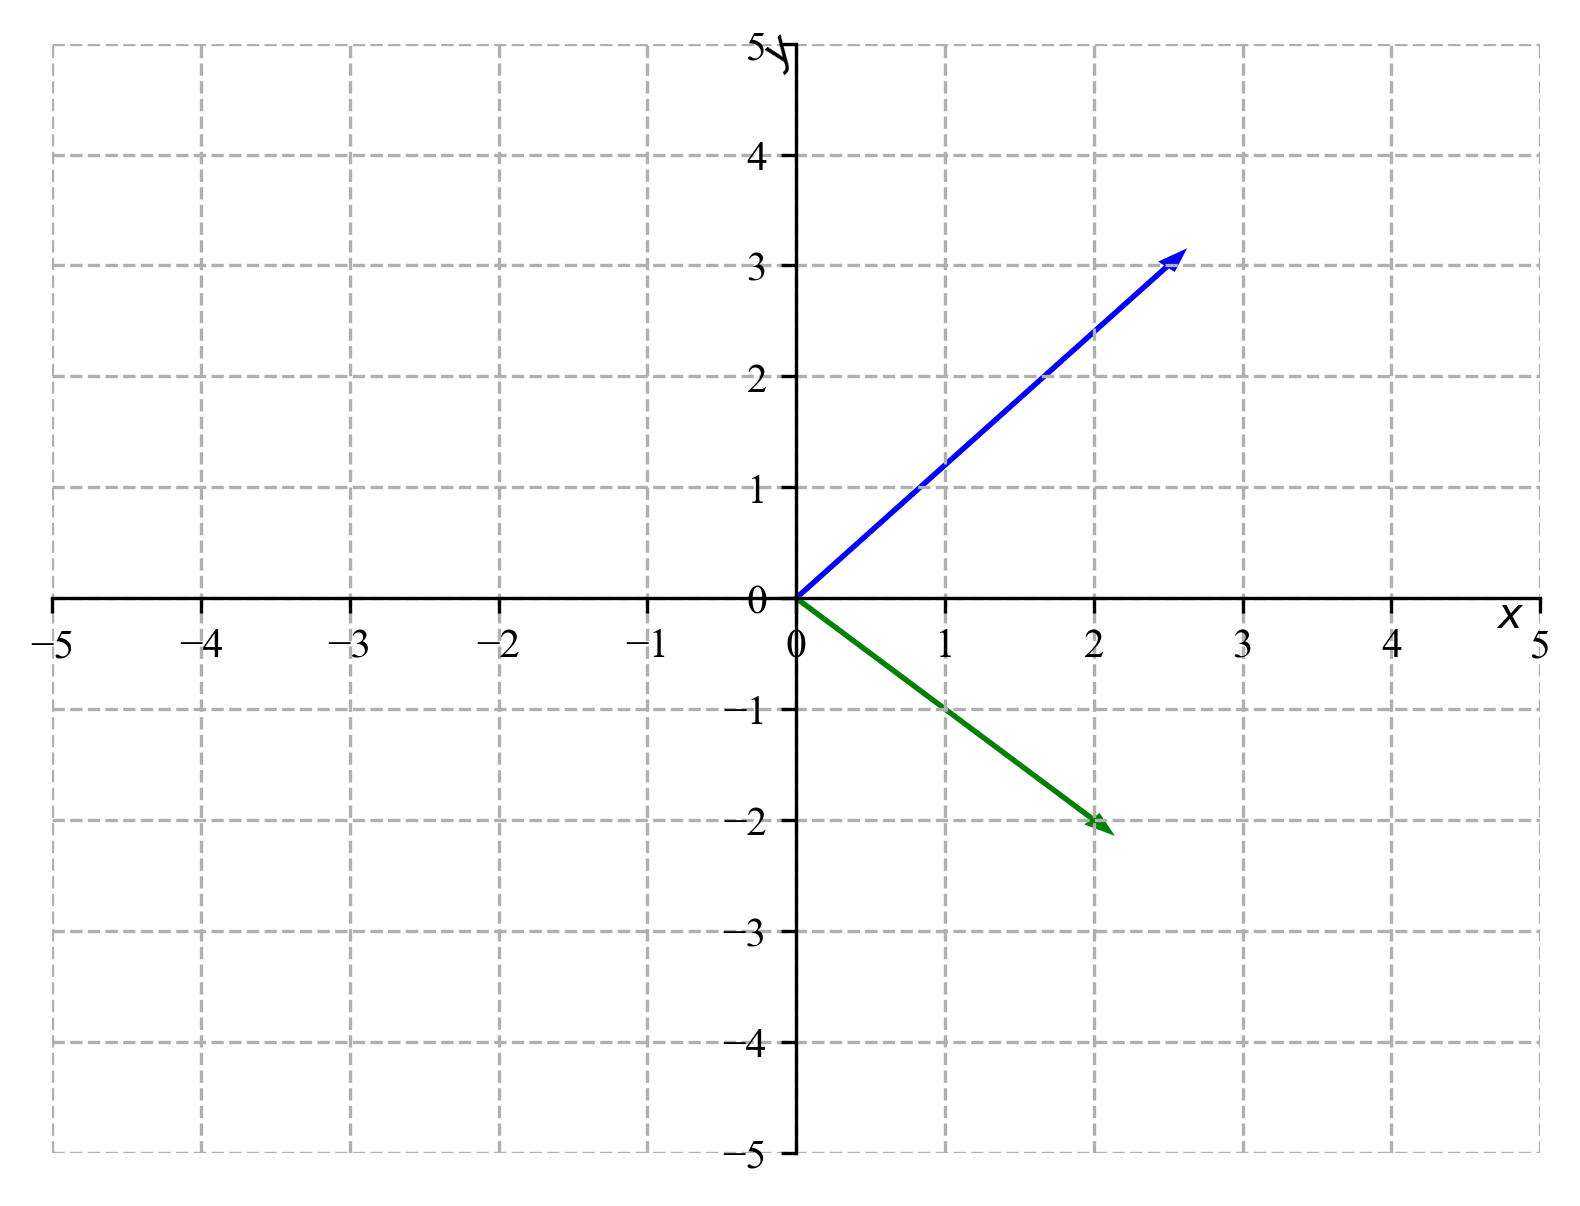

In [33]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.set_xlim((-5,5))
ax.set_ylim((-5,5))
ax.set_xticks(range(-5,6,1))
ax.set_yticks(range(-5,6,1))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation=45)
ax.xaxis.set_label_coords(0.98, 0.5) 
ax.yaxis.set_label_coords(0.5, 0.98) 

ax.grid(ls='--', linewidth=0.8)

dot1 = [2, -2]
dot2 = [2.5, 3]

x = [dot1[0], dot2[0]]
y = [dot1[1], dot2[1]]


cos = (dot1[0]*dot2[0] + dot1[1]*dot2[1])/(np.sqrt(dot1[0]**2 + dot1[1]**2)*np.sqrt(dot2[0]**2 + dot2[1]**2))

angle1 = np.arctan2(dot1[0], dot1[1])
angle2 = np.arctan2(dot2[0], dot2[1])
degrees = np.degrees(angle1 - angle2)
angle_difference = (angle2 - angle1) % np.pi  # range == [0, 2*pi)
angle_difference = angle_difference if angle_difference < np.pi else -2*np.pi + angle_difference

print(angle1, angle2)
print((angle2 - angle1) % np.pi)
print(degrees)
print(np.arctan2(y,x) * 180 / np.pi)


farrow1 = mpatches.FancyArrow(x=0, y=0, dx=dot1[0], dy=dot1[1] , width=0.01, head_width=0.1, color='g')
farrow2 = mpatches.FancyArrow(x=0, y=0, dx=dot2[0], dy=dot2[1] , width=0.01, head_width=0.1, color='b')
ax.add_patch(farrow1)
ax.add_patch(farrow2)

plt.show()

In [ ]:
import numpy as np
def unit_vector(vector):
    return vector / np.linalg.norm(vector)
def angle_between(v1, v2):
    
    """ Returns the angle in radians between vectors 'v1' and 'v2'::
            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

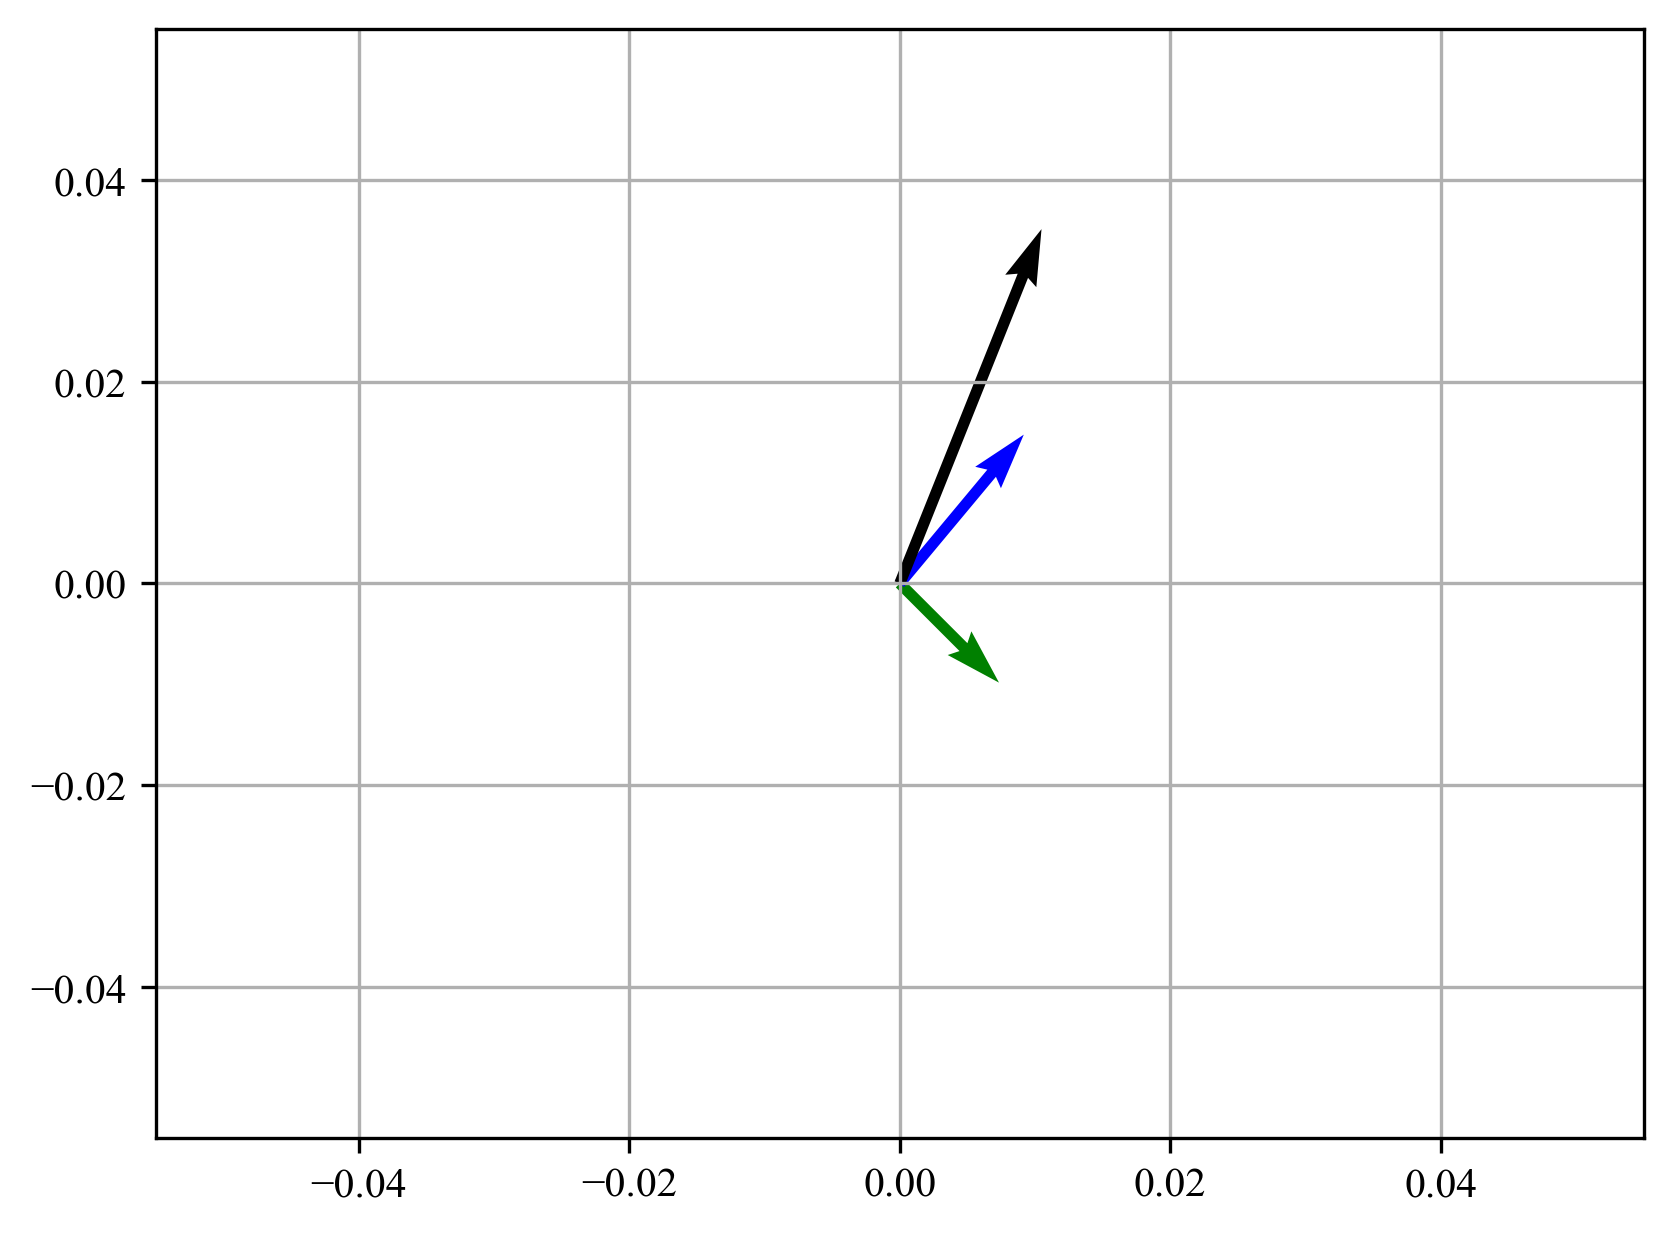

In [44]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.grid(True)
V = np.array([dot1, dot2])
origin = np.array([[0, 0],[0, 0]]) # origin point
plt.quiver(*origin, V[:,0], V[:,1], color=['g','b'], scale=30)
plt.quiver(0,0,2,5,scale=21)
plt.show()

In [ ]:
def angle(dot1, dot2):
    if dot1[0] > 0 and dot2[0] > 0:
        if dot1[1] < dot2[1]:
            return math.degrees(math.acos(cos))
        else:
            return -math.degrees(math.acos(cos))
    elif dot1[0] > 0 and dot2[0] < 0:

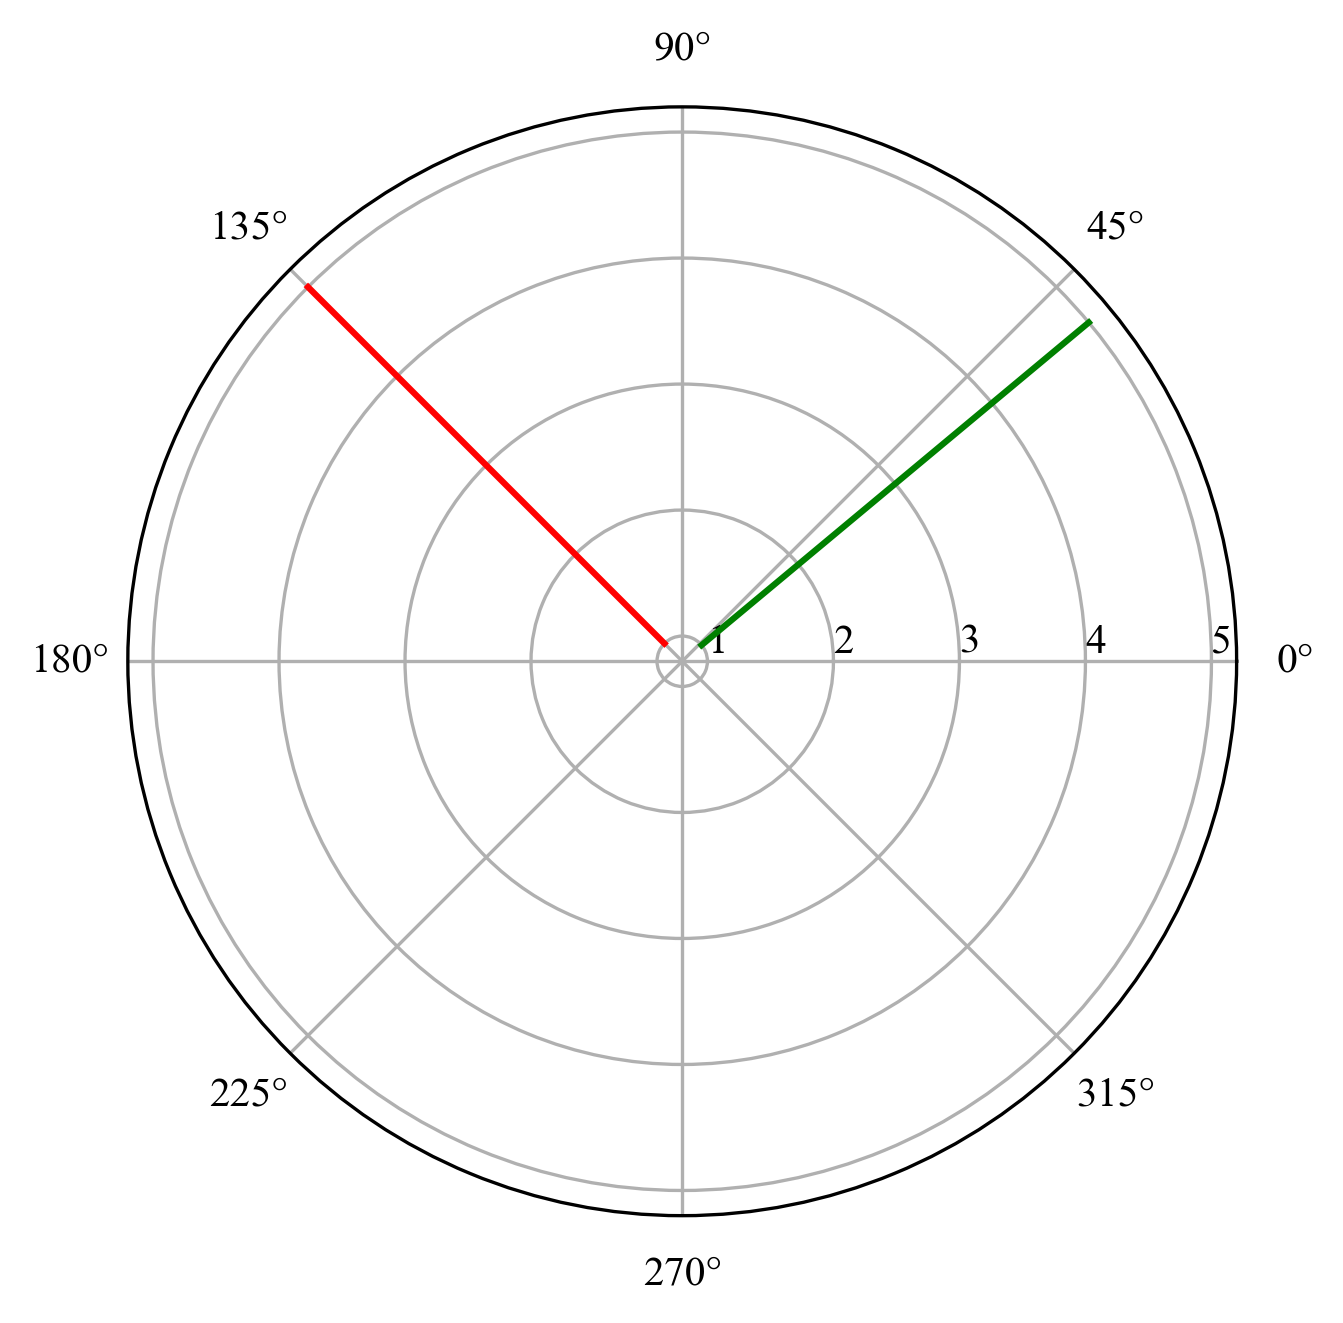

In [43]:
fig = plt.figure()
ax = plt.subplot(projection = 'polar')
ax.set_rticks(np.arange(1,6,1))
ax.set_rlabel_position(0)
r = np.arange(1, 6, 1)
theta = [angle1,angle1,angle1,angle1,angle1]
r2 = np.arange(1, 6, 1)
theta2 = [angle2, angle2, angle2, angle2, angle2]
ax.plot(theta, r,color='red')
ax.plot(theta2, r2, color='green')


plt.grid(True)
plt.show()

### Задание 3

Написать программу, которая рисует произвольный многоугольник по заданным координатам всех его вершин. Должна быть возможность задавать любое количество вершин в виде массива точек.

- Вычислите ориентированную площадь многоугольника. Проверьте корректность вычислений на примере правильного многоугольника, площадь которого можно вычислить теоретически. Простейший пример изображен на рисунке 5.
- Приведите пример преобразования, которое меняет знак ориентированной площади многоугольника. Пример изображен на рисунке 6. Примените это преобразование к вашему многоугольнику.
- Выделите вершины многоугольника маркерными точками. Как настроить размер маркеров? Цвет? Форму?
- Покажите стрелками направление обхода вершин, как это показано на рисунках 5 и 6.

В Matplotlib для рисования многоугольника используйте функцию Polygon из подмодуля Matplotlib.patches, а для правильного многоугольника — функцию RegularPolygon.

Введите количество вершин: 3
Введите 1 вершину: 1 1
Введите 2 вершину: 1 3
Введите 3 вершину: 4 1
0 5


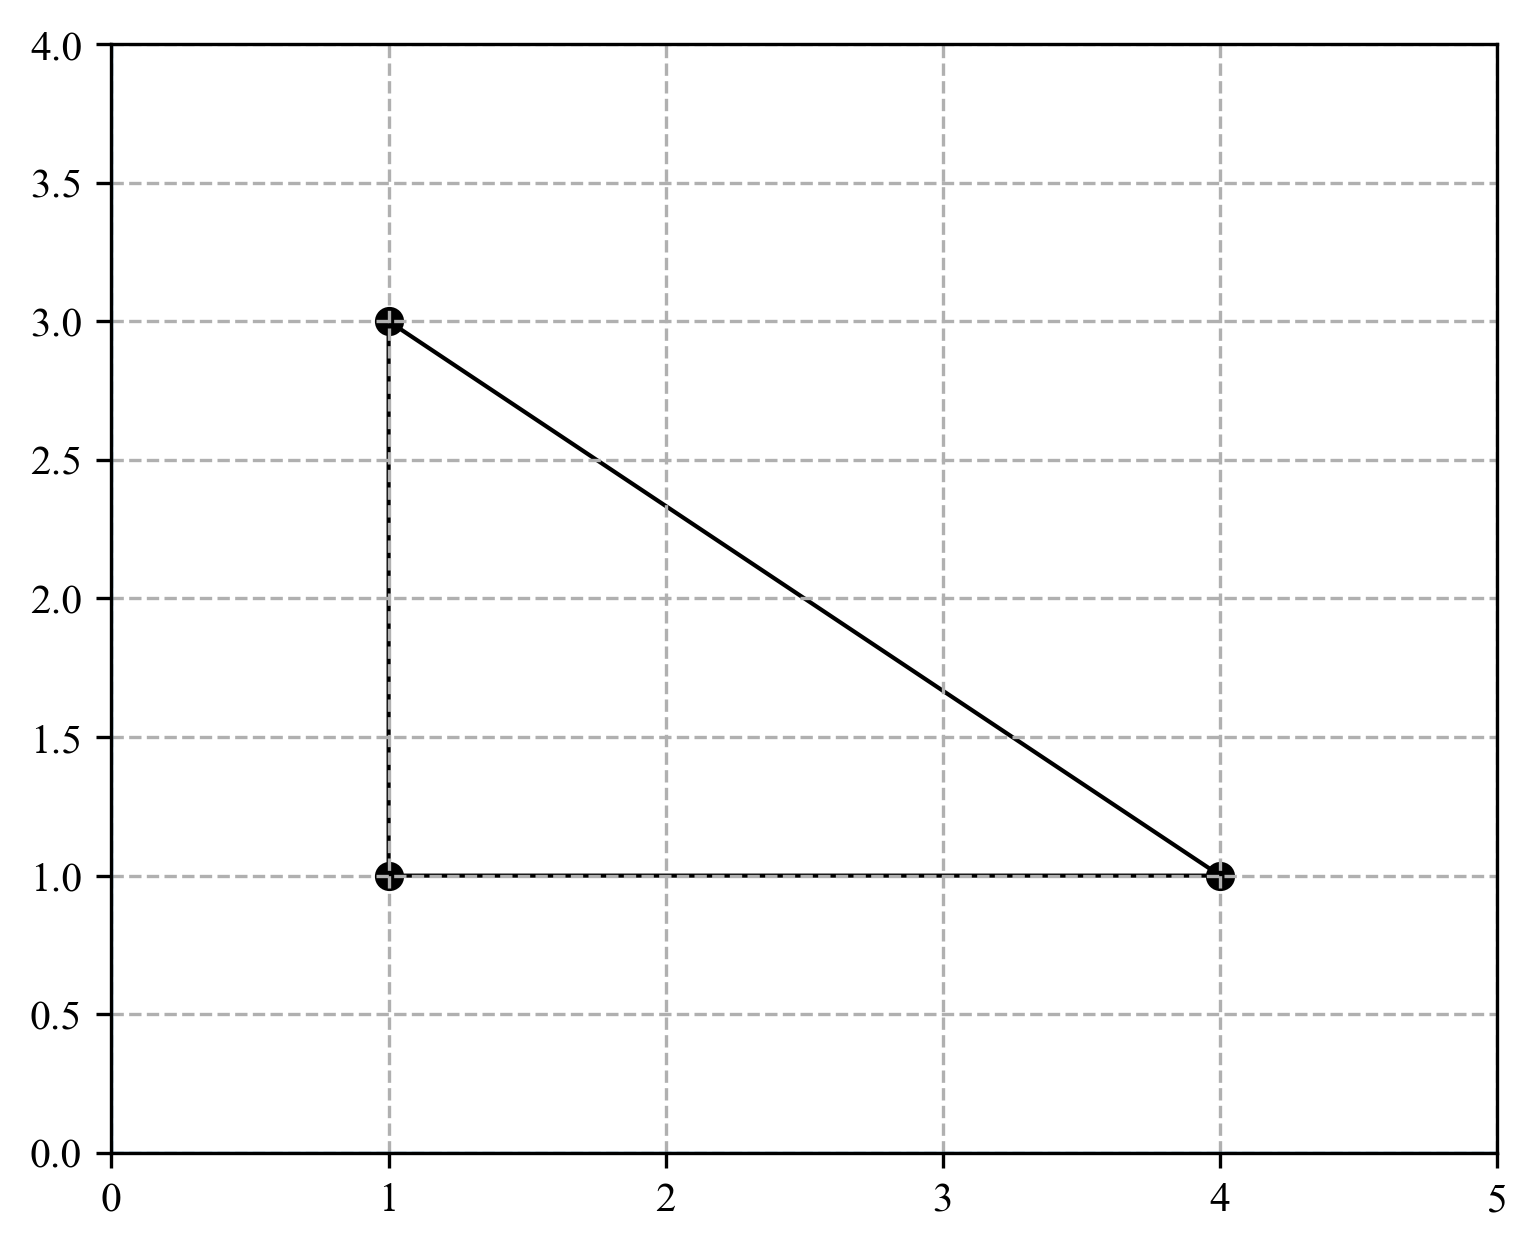

In [29]:
d = int(input('Введите количество вершин: '))
dots = []
xs = []
ys = []

for i in range(d):
    dot = input(f'Введите {i+1} вершину: ')
    dots.append(list(dot.split(' ')))
    xs.append(list(dot.split(' '))[0])
    ys.append(list(dot.split(' '))[1])
    
dots = [[int(i) for i in j] for j in dots]
xs = [int(i) for i in xs]
ys = [int(i) for i in ys]

    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.set(xlim=(min(xs)-1, max(xs)+1), ylim=(min(ys)-1, max(ys)+1), aspect='equal')
ax.grid(True, ls='--')

ax.axvline(x=0, ymin=min(ys)-1, ymax=max(ys)+1, linewidth=0.8)
ax.axhline(y=0, xmin=min(xs)-1, xmax=max(xs)+1, linewidth=0.8)


polygon = mpatches.Polygon(xy=np.array(dots), closed=True, fill=False)
ax.scatter(xs,ys,color='black')
ax.add_patch(polygon)

plt.show()

### Задание 4

Нарисуйте график циклоиды для двух полных оборотов окружности. Отобразите единичные касательные и нормальные векторы в некоторых точках циклоиды. см рис. 7. Уравнение циклоиды:

$$
𝐫(𝑡) = {x(𝑡) \choose 𝑦(𝑡)} = 
\begin{equation}
\left\{ 
\begin{array}{ll} 
𝑟(𝑡 − sin 𝑡)\\
𝑟(1 − cos 𝑡)\end{array}\right.
\end{equation}
$$

Касательный вектор вычисляется как производная от радиус вектора 𝐫 следующим образом:
$$
𝐯(𝑡) = \frac{dr}{d𝑡},
$$
а нормальный вектор 𝐧 получается из касательного поворотом на 90∘ против часовой стрелки.

Для визуализации поля векторов с помощью Matplotlib можно использовать функцию quiver.

### Задание 5

Написать программу, которая рисует правильный многоугольник с центром в заданной точке, а также вписанную и описанную окружности этого многоугольника см. рис. 8. Количество сторон правильного 𝑛-угольника и длину его стороны нужно задать в виде параметра. Вместо длины стороны можно использовать радиус 𝑟 вписанной или радиус 𝑅 описанной окружностей.
- Все вершины многоугольника должны быть выделены маркерами и подписаны как 𝑃1, 𝑃2 и т.д. Нумерация точек должна осуществляться автоматически, в зависимости от 𝑛.
- Радиусы окружностей должны быть нарисованы в виде отрезков.
- Стороны многоугольника должны быть нарисованы более толстыми линиями, чем остальные элементы изображения.
- Описанная и вписанная окружности должны быть нарисованы разными цветами.
- Масштаб изображения не должен быть искажен (окружности не должны выглядеть как эллипсы).
- Картинка должна корректно перерисовываться при изменении $n$

### Задание 6

Нарисовать конические сечения: эллипс, гиперболу и параболу в каноническом виде. Для этого удобнее всего воспользоваться параметрическими формулами:

$$
𝐫(𝑡) = {𝑎 cos(𝑡) \choose 𝑏 sin(𝑡)}  𝐫(𝑡) = {𝑎 ch(𝑡) \choose 𝑏 sh(𝑡)} 𝐫(𝑡) = {𝑎𝑡^2 \choose 2𝑎𝑡} 
$$
